In [1]:
# This installs the Ultralytics library which contains YOLOv8
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 18.6 MB/s eta 0:00:00


In [2]:
from ultralytics import YOLO

model = YOLO('yolov8s.pt')

print("Model loaded successfully")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Model loaded successfully


In [3]:
# Download a test image from the internet into our Colab session
import urllib.request

url = "https://ultralytics.com/images/zidane.jpg"

urllib.request.urlretrieve(url, "test_image.jpg")

print("Image downloaded")

Image downloaded


In [4]:
import torch
print(f"Using PyTorch version: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
results = model('test_image.jpg')

result = results[0]

print("Objects detected:")
for box in result.boxes:
    class_id = int(box.cls)
    class_name = result.names[class_id]

    confidence = round(float(box.conf), 2)

    print(f"  - {class_name}: {confidence * 100}% confident")


Using PyTorch version: 2.10.0+cu128
GPU available: True

image 1/1 /content/test_image.jpg: 384x640 2 persons, 1 tie, 214.2ms
Speed: 18.0ms preprocess, 214.2ms inference, 73.6ms postprocess per image at shape (1, 3, 384, 640)
Objects detected:
  - person: 89.0% confident
  - person: 88.0% confident
  - tie: 72.0% confident


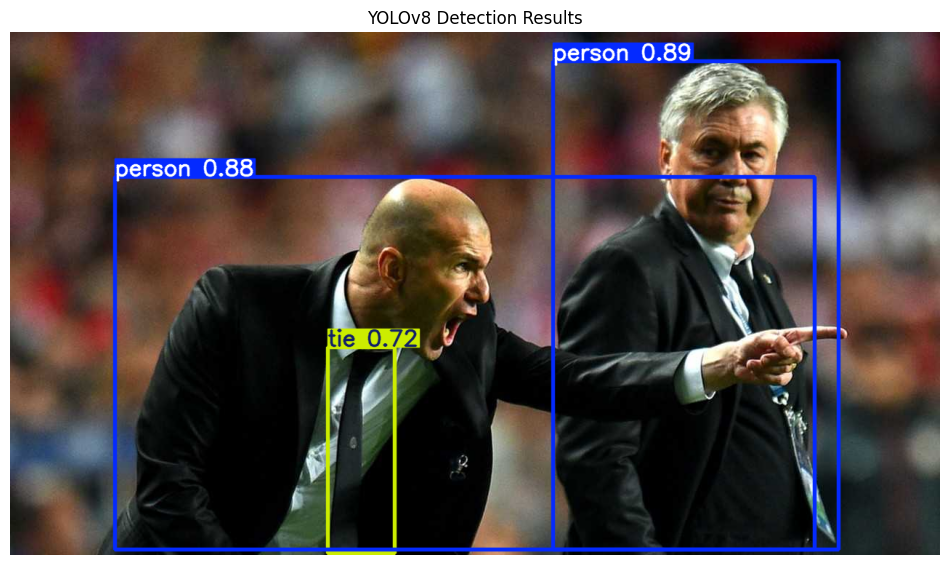

In [5]:
# These libraries let us display images inside Colab
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# result.plot() returns the image with bounding boxes already drawn on it
annotated_image = result.plot()

# matplotlib expects RGB but OpenCV gives BGR - this line fixes the colours
annotated_image_rgb = annotated_image[:, :, ::-1]

plt.figure(figsize=(12, 8))
plt.imshow(annotated_image_rgb)
plt.axis('off')
plt.title("YOLOv8 Detection Results")
plt.show()

In [6]:
# Set  threshold - only keep detections AT or ABOVE this confidence level
CONFIDENCE_THRESHOLD = 0.5   # 50% for now - can change later

print(f"Detections above {CONFIDENCE_THRESHOLD * 100}% confidence:")
print("-" * 40)

# Keep a count so we know how many passed the filter
kept = 0
removed = 0

for box in result.boxes:
    confidence = float(box.conf)
    class_id = int(box.cls)
    class_name = result.names[class_id]

    if confidence < CONFIDENCE_THRESHOLD:
        removed += 1
        continue

    print(f"  - {class_name}: {round(confidence * 100, 1)}%")
    kept += 1

print("-" * 40)
print(f"Kept: {kept} detections")
print(f"Removed: {removed} low-confidence detections")

Detections above 50.0% confidence:
----------------------------------------
  - person: 88.9%
  - person: 88.4%
  - tie: 71.8%
----------------------------------------
Kept: 3 detections
Removed: 0 low-confidence detections


In [7]:
import cv2
import os

# result.plot() gives us the image with boxes drawn on it
annotated_image = result.plot()

# Save it as a new file
output_path = "detection_result.jpg"
cv2.imwrite(output_path, annotated_image)

file_size = os.path.getsize(output_path)
print(f"Saved to: {output_path}")
print(f"File size: {file_size} bytes")

detections = [box for box in result.boxes if float(box.conf) >= CONFIDENCE_THRESHOLD]
print(f"Objects detected: {len(detections)}")
for box in detections:
    class_name = result.names[int(box.cls)]
    confidence = round(float(box.conf) * 100, 1)
    print(f"  - {class_name}: {confidence}%")

Saved to: detection_result.jpg
File size: 156284 bytes
Objects detected: 3
  - person: 88.9%
  - person: 88.4%
  - tie: 71.8%


In [8]:
# A list of test images to run through
test_urls = [
    "https://ultralytics.com/images/bus.jpg",
    "https://ultralytics.com/images/zidane.jpg",
]

all_results = []

# Loop through each image one by one
for i, url in enumerate(test_urls):

    img_filename = f"test_image_{i}.jpg"
    urllib.request.urlretrieve(url, img_filename)

    # Run YOLO detection with confidence filter built in
    results = model(img_filename, conf=CONFIDENCE_THRESHOLD)
    result = results[0]

    # Collect the detections for this image
    detections = []
    for box in result.boxes:
        detections.append({
            "class": result.names[int(box.cls)],
            "confidence": round(float(box.conf) * 100, 1)
        })

    annotated = result.plot()
    cv2.imwrite(f"result_{i}.jpg", annotated)

    # Store everything about this image
    all_results.append({
        "image": img_filename,
        "num_detections": len(detections),
        "detections": detections
    })

    print(f"Image {i+1}: {img_filename}")
    print(f"  Found {len(detections)} objects:")
    for d in detections:
        print(f"    - {d['class']}: {d['confidence']}%")
    print()

print("=" * 40)
print(f"Processed {len(all_results)} images total")


image 1/1 /content/test_image_0.jpg: 640x480 4 persons, 1 bus, 90.7ms
Speed: 8.5ms preprocess, 90.7ms inference, 2.4ms postprocess per image at shape (1, 3, 640, 480)
Image 1: test_image_0.jpg
  Found 5 objects:
    - bus: 92.1%
    - person: 89.3%
    - person: 88.7%
    - person: 87.8%
    - person: 61.1%


image 1/1 /content/test_image_1.jpg: 384x640 2 persons, 1 tie, 16.1ms
Speed: 2.1ms preprocess, 16.1ms inference, 2.0ms postprocess per image at shape (1, 3, 384, 640)
Image 2: test_image_1.jpg
  Found 3 objects:
    - person: 88.9%
    - person: 88.4%
    - tie: 71.8%

Processed 2 images total


In [9]:
def run_detection(image_path, confidence=0.5, save_result=True):

    # Run YOLO on the image with confidence filter
    results = model(image_path, conf=confidence)
    result = results[0]

    # This gets passed to Person 2 for BLIP captioning
    detected_objects = []
    for box in result.boxes:
        class_name = result.names[int(box.cls)]
        detected_objects.append(class_name)

    # Draw bounding boxes on the image
    annotated_image = result.plot()

    result_path = None
    if save_result:
        result_path = image_path.replace(".jpg", "_detected.jpg")
        cv2.imwrite(result_path, annotated_image)

    return detected_objects, annotated_image, result_path


# how Person 4 will call the code in the main notebook

objects, image, saved_path = run_detection("test_image_0.jpg")

print("Function works correctly!")
print(f"Detected objects: {objects}")
print(f"Result saved to:  {saved_path}")


image 1/1 /content/test_image_0.jpg: 640x480 4 persons, 1 bus, 13.4ms
Speed: 3.3ms preprocess, 13.4ms inference, 2.0ms postprocess per image at shape (1, 3, 640, 480)
Function works correctly!
Detected objects: ['bus', 'person', 'person', 'person', 'person']
Result saved to:  test_image_0_detected.jpg


<IPython.core.display.Javascript object>

Waiting for photo to save...
File ready after 0s — running detection...


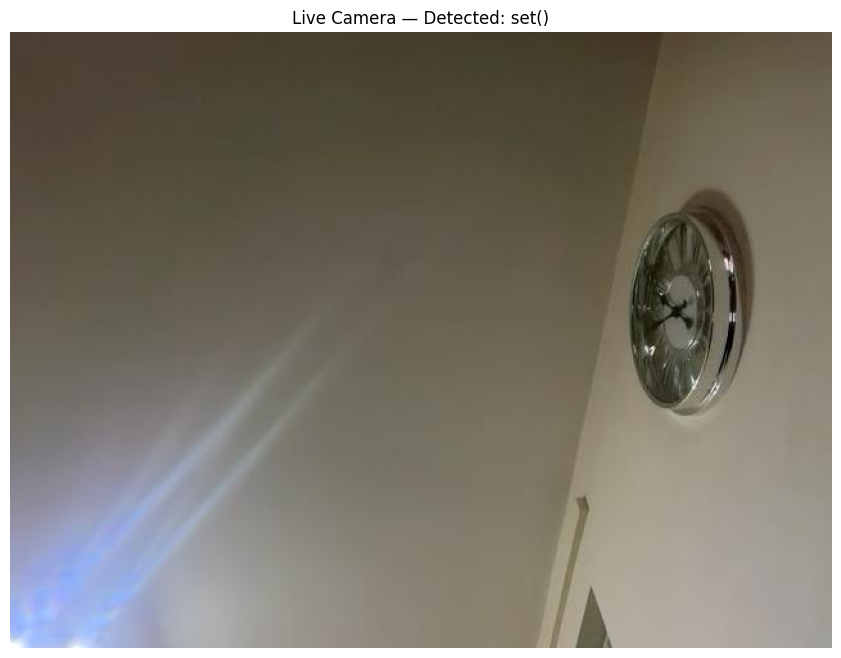

Objects found: []
Photo saved successfully!


In [14]:
from IPython.display import display, Javascript
from google.colab.output import eval_js
from base64 import b64decode
from PIL import Image
import io
import time
import os
import matplotlib.pyplot as plt

# Callback that receives the image from JavaScript and saves it
def save_image(image_b64):
    image_bytes = b64decode(image_b64.split(',')[1])
    image = Image.open(io.BytesIO(image_bytes))
    image.save("camera_capture.jpg")
    print("Photo saved successfully!")

from google.colab import output
output.register_callback("notebook.captureResult", save_image)

# Launch the camera
display(Javascript('''
    async function capture() {
        const div = document.createElement("div");
        const video = document.createElement("video");
        const canvas = document.createElement("canvas");

        document.body.appendChild(div);
        div.appendChild(video);

        const stream = await navigator.mediaDevices.getUserMedia({video: true});
        video.srcObject = stream;
        await video.play();

        await new Promise(r => setTimeout(r, 2000));

        canvas.width = video.videoWidth;
        canvas.height = video.videoHeight;
        canvas.getContext("2d").drawImage(video, 0, 0);
        stream.getTracks().forEach(t => t.stop());
        div.remove();

        const result = canvas.toDataURL("image/jpeg");
        google.colab.kernel.invokeFunction("notebook.captureResult", [result], {});
    }
    capture();
'''))

# Wait until the file actually exists before running YOLO
# Check every 0.5 seconds, give up after 15 seconds
print("Waiting for photo to save...")
max_wait = 15
waited = 0
while not os.path.exists("camera_capture.jpg") and waited < max_wait:
    time.sleep(0.5)
    waited += 0.5

# Now check if we actually got the file
if not os.path.exists("camera_capture.jpg"):
    print("Camera timed out - try running the cell again")
else:
    print(f"File ready after {waited}s — running detection...")

    # Run detection on the captured photo
    objects, annotated, saved = run_detection("camera_capture.jpg")

    annotated_rgb = annotated[:, :, ::-1]
    plt.figure(figsize=(12, 8))
    plt.imshow(annotated_rgb)
    plt.axis('off')
    plt.title(f"Live Camera — Detected: {set(objects)}")
    plt.show()

    print(f"Objects found: {objects}")

In [11]:
# basic detenction done, COCO dataset training below


In [12]:
import os
import json
import csv
import time
import cv2
from ultralytics import YOLO
import torch

IMAGE_FOLDER      = "../data/coco_test"
ANNOTATIONS_PATH  = "../data/annotations/selected_annotations.json"
RESULTS_FILE      = "../data/detection_results.csv"
CONFIDENCE        = 0.5

print(f"PyTorch version: {torch.__version__}")
print(f"GPU available:   {torch.cuda.is_available()}")
model = YOLO("yolov8s.pt")
print("Model loaded\n")

# Detection function
def run_detection(image_path, confidence=0.5, save_result=True):
    results     = model(image_path, conf=confidence, verbose=False)
    result      = results[0]
    objects     = [result.names[int(b.cls)] for b in result.boxes]
    annotated   = result.plot()
    result_path = None

    if save_result:
        result_path = image_path.replace(".jpg", "_detected.jpg")
        cv2.imwrite(result_path, annotated)

    return objects, annotated, result_path

# Load ground truth annotations

with open(ANNOTATIONS_PATH) as f:
    ground_truth = json.load(f)

selected_images = list(ground_truth.keys())
print(f"Images to process: {len(selected_images)}")
print(f"Sample: {selected_images[:3]}\n")

#  Run detection on all 50 images

with open(RESULTS_FILE, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "image_name",
        "num_detections",
        "objects_detected",
        "ground_truth_objects",
        "confidence_scores",
        "avg_confidence",
        "processing_time_ms"
    ])

print(f"Running detection on {len(selected_images)} images...")
print("-" * 50)

for i, filename in enumerate(selected_images):
    image_path = os.path.join(IMAGE_FOLDER, filename)

    start       = time.time()
    results_raw = model(image_path, conf=CONFIDENCE, verbose=False)
    end         = time.time()

    result_raw     = results_raw[0]
    processing_ms  = round((end - start) * 1000, 1)
    objects        = [result_raw.names[int(b.cls)] for b in result_raw.boxes]
    confidences    = [round(float(b.conf) * 100, 1) for b in result_raw.boxes]
    avg_conf       = round(sum(confidences) / len(confidences), 1) if confidences else 0
    gt_objects     = ground_truth[filename]

    with open(RESULTS_FILE, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            filename,
            len(objects),
            ", ".join(objects) if objects else "none",
            ", ".join(gt_objects),
            ", ".join(str(c) for c in confidences) if confidences else "none",
            avg_conf,
            processing_ms
        ])

    print(f"  {i+1}/50 — {filename} — found {len(objects)} — GT had {len(gt_objects)} — {processing_ms}ms")

print("-" * 50)
print(f"Done. Results saved to {RESULTS_FILE}")

PyTorch version: 2.10.0+cu128
GPU available:   True
Model loaded



FileNotFoundError: [Errno 2] No such file or directory: '../data/annotations/selected_annotations.json'

In [ ]:
import csv
import os
import time

results_file = "detection_results.csv"

with open(results_file, "w", newline="") as f:
    writer = csv.writer(f)
    writer.writerow([
        "image_name",
        "num_detections",
        "objects_detected",
        "confidence_scores",
        "avg_confidence",
        "processing_time_ms"
    ])

print(f"Results will be saved to: {results_file}")
print(f"Running detection on {len(selected_images)} images...")
print("-" * 50)

for i, filename in enumerate(selected_images):
    image_path = f"../data/coco_test/{filename}"

    # Run YOLO once only
    start       = time.time()
    results_raw = model(image_path, conf=0.5, verbose=False)
    end         = time.time()

    result_raw    = results_raw[0]
    processing_ms = round((end - start) * 1000, 1)
    objects       = [result_raw.names[int(b.cls)] for b in result_raw.boxes]
    confidences   = [round(float(b.conf) * 100, 1) for b in result_raw.boxes]
    avg_conf      = round(sum(confidences) / len(confidences), 1) if confidences else 0

    with open(results_file, "a", newline="") as f:
        writer = csv.writer(f)
        writer.writerow([
            filename,
            len(objects),
            ", ".join(objects) if objects else "none",
            ", ".join(str(c) for c in confidences) if confidences else "none",
            avg_conf,
            processing_ms
        ])

    print(f"  {i+1}/50 — {filename} — found {len(objects)} objects — {processing_ms}ms")

print("-" * 50)
print(f"Done. Results saved to {results_file}")

In [ ]:
import csv

total_detections = 0
all_times = []
object_counts = []

with open("detection_results.csv") as f:
    reader = csv.DictReader(f)
    for row in reader:
        total_detections += int(row["num_detections"])
        all_times.append(float(row["processing_time_ms"]))
        object_counts.append(int(row["num_detections"]))

print("── Results Summary ──────────────────")
print(f"Images processed:      50")
print(f"Total detections:      {total_detections}")
print(f"Avg detections/image:  {round(total_detections/50, 1)}")
print(f"Avg processing time:   {round(sum(all_times)/len(all_times), 1)}ms")
print(f"Fastest image:         {min(all_times)}ms")
print(f"Slowest image:         {max(all_times)}ms")
print(f"Most objects in one image: {max(object_counts)}")
print(f"Images with 0 detections:  {object_counts.count(0)}")